# 12 — Animating data on the globe

The globe is a static frame, but nothing stops us **animating a stack of rasters** over it. This notebook shows two kinds of globe animation, both built on `matplotlib.animation.FuncAnimation`:

1. **Time animation** — step a *stack* of grids (the 12 monthly WorldClim temperature fields) frame by frame to watch the seasons move.
2. **Rotating globe** — keep one field (global elevation) and sweep the orthographic centre longitude to spin the Earth.

Each frame is a full `Map(globe=True)` draw — pyramids reprojects the grid, cleopatra renders it, and the projection frame is applied — so animations get coastlines, graticule, and limb-clipping for free. (cleopatra's `ArrayGlyph.animate` animates a plain 3-D array; the globe needs this per-frame reproject-and-frame orchestration, so we drive `FuncAnimation` here.)

> The GIFs are written to a temp file and embedded into the notebook output, so nothing extra is committed. WorldClim downloads on first run (cached, git-ignored).

## Setup & data

Download the monthly temperature stack and the global elevation grid (cached).

In [1]:
%matplotlib inline
import io, os, zipfile, tempfile, urllib.request as u
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
from pyramids.dataset import Dataset
from digitalearth.scene import Map, projections

CACHE = Path('examples/data/global'); CACHE.mkdir(parents=True, exist_ok=True)
BASE = 'https://geodata.ucdavis.edu/climate/worldclim/2_1/base/'

def fetch(product):
    """Download+unzip a WorldClim 10m product, returning the sorted cached GeoTIFF paths."""
    tifs = sorted(CACHE.glob(f'{product}*.tif'))
    if not tifs:
        blob = u.urlopen(u.Request(BASE + f'{product}.zip', headers={'User-Agent': 'Mozilla/5.0'}),
                         timeout=300).read()
        with zipfile.ZipFile(io.BytesIO(blob)) as z:
            for n in z.namelist():
                if n.endswith('.tif'):
                    (CACHE / os.path.basename(n)).write_bytes(z.read(n))
        tifs = sorted(CACHE.glob(f'{product}*.tif'))
    return tifs

MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
tavg = [Dataset.read_file(str(p)) for p in fetch('wc2.1_10m_tavg')]   # 12-grid stack
elevation = Dataset.read_file(str(fetch('wc2.1_10m_elev')[0]))
print('stack:', len(tavg), 'monthly grids; elevation:', elevation.rows, 'x', elevation.columns)

2026-05-31 22:46:12 | INFO | pyramids.base.config | Logging is configured.


stack: 12 monthly grids; elevation: 1080 x 2160


## The animation helper

One small driver: it clears the axes, calls a per-frame `draw(ax, fig, i)` that builds a globe, saves the frames to a GIF with `PillowWriter`, and embeds the GIF bytes into the notebook output. A `safe_coast` helper keeps coastlines from breaking the run offline.

In [2]:
def safe_coast(m):
    """Draw coastlines if Natural Earth is reachable; never raise."""
    try:
        m.coastlines(resolution='110m')
    except Exception:
        pass

def animate_globe(draw, n_frames, *, fps=3, figsize=(5.5, 5.5)):
    """Render an `n_frames` globe animation via FuncAnimation and embed it as a GIF in the output.

    Args:
        draw: callback ``draw(ax, fig, i)`` that builds frame ``i`` on the given axes.
        n_frames: number of frames.
        fps: frames per second of the saved GIF.
        figsize: figure size in inches.
    Returns:
        IPython.display.Image wrapping the animated GIF (embedded, no file committed).
    """
    fig, ax = plt.subplots(figsize=figsize)
    anim = FuncAnimation(fig, lambda i: (ax.clear(), draw(ax, fig, i)), frames=n_frames,
                         interval=1000 / fps, blit=False)
    tmp = tempfile.NamedTemporaryFile(suffix='.gif', delete=False).name
    anim.save(tmp, writer=PillowWriter(fps=fps))
    plt.close(fig)
    data = Path(tmp).read_bytes(); os.remove(tmp)
    print(f'{n_frames} frames, {len(data) / 1e3:.0f} kB')
    return Image(data=data, format='gif')

## 1. Seasonal time animation (a stack of 12 grids)

Step the monthly temperature stack on a fixed orthographic globe centred on Africa. Watch the warm band swing north in July and south in January. A fixed `vmin`/`vmax` keeps the colours comparable across frames.

12 frames, 733 kB


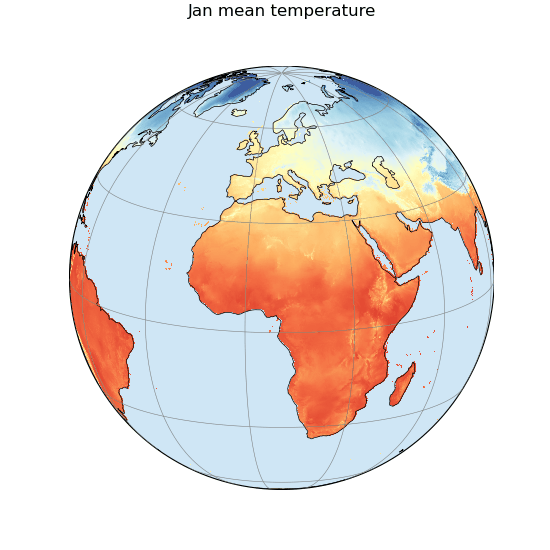

In [3]:
CRS = projections.orthographic(lon=10, lat=15)

def draw_month(ax, fig, i):
    m = Map(crs=CRS, globe=True, ax=ax, fig=fig)
    m.ocean()
    m.imshow(tavg[i], cmap='RdYlBu_r', vmin=-40, vmax=40)
    safe_coast(m)
    m.graticule(lon_step=30, lat_step=30)
    m.set_global()
    m.set_title(f'{MONTHS[i]} mean temperature')
    m.render()

animate_globe(draw_month, len(tavg), fps=3)

## 2. Rotating globe (one field, swept longitude)

Keep the global elevation field and sweep the orthographic centre longitude through 360 degrees to spin the Earth. Ocean cells are nodata, so the `ocean()` disc shows through the sea.

24 frames, 1511 kB


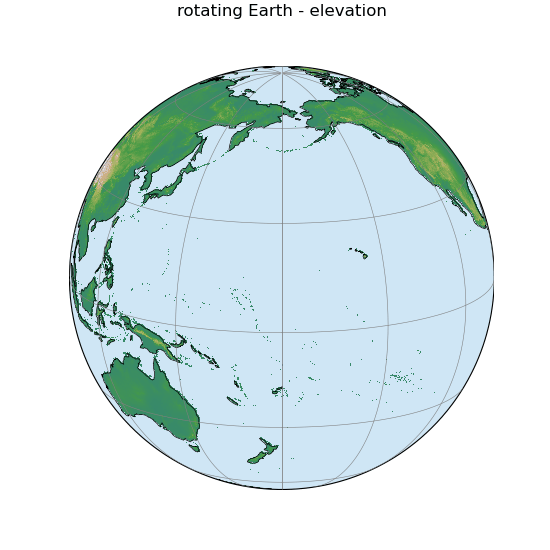

In [4]:
N = 24

def draw_spin(ax, fig, i):
    lon = -180 + i * (360 / N)
    m = Map(crs=projections.orthographic(lon=lon, lat=15), globe=True, ax=ax, fig=fig)
    m.ocean()
    m.imshow(elevation, cmap='gist_earth', vmin=-3000, vmax=5000)
    safe_coast(m)
    m.graticule(lon_step=30, lat_step=30)
    m.set_global()
    m.set_title('rotating Earth - elevation')
    m.render()

animate_globe(draw_spin, N, fps=8)

## Notes

- **Stacks.** Here the stack is a list of `Dataset`s; pyramids' `DatasetCollection` (a datacube) is the natural container for a real time stack and indexes the same way.
- **Cost.** Each frame is a full reproject + frame, so animations are heavier than a single map; keep the frame count and figure size modest, or pre-reproject once and swap the image array for speed.
- **Where it could live.** A reusable `Map.animate(stack, ...)` belongs in Digital-Earth as orchestration over cleopatra's animation + pyramids' reprojection — this notebook is the working recipe for it.